In [1]:
"""
Script de traitement des données de limites planétaires (LP)
Génère un graphique en barres empilées représentant les LP par sous-processus
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

In [2]:
# ============================================================================
# 1. PARAMÈTRES GLOBAUX
# ============================================================================

BASE_DIR = r"C:\Users\Arnaud\Documents\PlaneFR\data"
BASE_DATA_DIR = r"C:\Users\Arnaud\Documents\PlaneFR\data\3.10.2"
FIGURES_DIR = r"C:\Users\Arnaud\Documents\PlaneFR\figures"
THRESHOLD_PARAM_LB = "Égalité"  # Peut être changé à "capacité" ou autre
THRESHOLD_PARAM_UB = "Égalité (limite haute)"  # Peut être changé à "capacité" ou autre


# Récupérer les dossiers de scénarios
SCENARIO_FOLDERS = sorted([d for d in Path(BASE_DATA_DIR).iterdir() if d.is_dir()])
SCENARIO_NAMES = [d.name for d in SCENARIO_FOLDERS]
REFERENCE_SCENARIO_IDX = 0  # "base-year_2015" est le premier

# Paths des fichiers source (communs à tous les scénarios)
FACTEURS_CARAC_FILE = Path(BASE_DIR) / "facteurs de caractérisation.xlsx"
BRIDGE_MATRICES_FILE = Path(BASE_DIR) / "bridge_matrices.xlsx"
SEUILS_FILE = Path(BASE_DIR) / "seuils.xlsx"

# Couleurs pour les 5 catégories de consommation
CATEGORY_COLORS = {
    0: "#1f77b4",  # Bleu
    1: "#ff7f0e",  # Orange
    2: "#2ca02c",  # Vert
    3: "#d62728",  # Rouge
    4: "#9467bd"   # Violet
}

# Fonctions utilitaires pour générer les nuances
def get_dark_shade(hex_color, factor=0.7):
    """Retourne une nuance foncée d'une couleur hex"""
    h = hex_color.lstrip('#')
    rgb = tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
    dark_rgb = tuple(int(c * factor) for c in rgb)
    return '#{:02x}{:02x}{:02x}'.format(*dark_rgb)

def get_light_shade(hex_color, factor=1.3):
    """Retourne une nuance claire d'une couleur hex"""
    h = hex_color.lstrip('#')
    rgb = tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
    light_rgb = tuple(min(255, int(c * factor)) for c in rgb)
    return '#{:02x}{:02x}{:02x}'.format(*light_rgb)


In [3]:
# ============================================================================
# 2. FONCTIONS DE CHARGEMENT DES DONNÉES
# ============================================================================

def load_facteurs_carac():
    """
    Charge le fichier des facteurs de caractérisation.
    
    Returns:
        pd.DataFrame: DataFrame contenant les colonnes:
            - "Sous-processus"
            - "processus du système Terre" (LP)
            - "extensions exiobase"
            - "facteur de caractérisation"
    """
    print("Chargement des facteurs de caractérisation...")
    df = pd.read_excel(FACTEURS_CARAC_FILE)
    print(f"  ✓ {len(df)} lignes chargées")
    return df


def load_bridge_matrices():
    """
    Charge la matrice bridge "Final conso. cat".
    
    Returns:
        pd.DataFrame: Matrice contenant les catégories de consommation
    """
    print("Chargement de la matrice bridge...")
    df = pd.read_excel(BRIDGE_MATRICES_FILE, sheet_name="Final conso. cat.")
    print(f"  ✓ Matrice de shape {df.shape}")
    return df


def load_seuils():
    """
    Charge le fichier des seuils.
    
    Returns:
        pd.DataFrame: DataFrame "synthèse" contenant:
            - Index: noms des LP (et lignes spéciales comme "nom LP", "correspondances", THRESHOLD_PARAM)
            - Colonnes: sous-processus
    """
    print("Chargement des seuils...")
    df = pd.read_excel(SEUILS_FILE, sheet_name="Synthèse", index_col=0)
    print(f"  ✓ {len(df)} lignes chargées")
    return df


def load_dls():
    """
    Charge la feuille DLS du fichier des seuils (planchers sociaux).
    
    Returns:
        pd.DataFrame: DataFrame "DLS" contenant les planchers sociaux
            - Index: noms des scénarios/seuils
            - Colonnes: sous-processus
    """
    print("Chargement des planchers sociaux (DLS)...")
    df = pd.read_excel(SEUILS_FILE, sheet_name="DLS", index_col=0)
    print(f"  ✓ {len(df)} lignes chargées")
    return df


def load_d_cba(scenario_folder_path, lp_name, origin="imp"):
    """
    Charge un fichier d_cba (demandes finales) pour un scénario spécifique.
    
    Args:
        scenario_folder_path (Path): Chemin du dossier du scénario
        lp_name (str): Nom du processus du système Terre (ex: "Eau", "Énergie")
        origin (str): "imp" pour importé, "dom" pour domestique
    
    Returns:
        pd.DataFrame: DataFrame des demandes finales
    """
    if origin == "imp":
        folder_name = f"imp_{lp_name}"
    else:
        folder_name = f"dom_{lp_name}"
    
    file_path = Path(scenario_folder_path) / "extensions" / folder_name / "d_cba_k.pkl"
    
    if not file_path.exists():
        print(f"  ⚠ Fichier non trouvé: {file_path}")
        return None
    
    df = pd.read_pickle(file_path)
    return df

In [4]:
# ============================================================================
# 3. FONCTIONS DE TRAITEMENT DES DONNÉES
# ============================================================================

def get_unique_subprocesses(facteurs_carac_df):
    """
    Extrait les sous-processus uniques et crée un mapping vers les LP.

    Args:
        facteurs_carac_df (pd.DataFrame): DataFrame des facteurs

    Returns:
        dict: Dictionnaire {sous-processus: [LP1, LP2, ...]}
    """
    subprocess_to_lp = {}
    for _, row in facteurs_carac_df.iterrows():
        subprocess = row["Sous-processus"]
        lp = row["Processus du système Terre"]
        if subprocess not in subprocess_to_lp:
            subprocess_to_lp[subprocess] = []
        if lp not in subprocess_to_lp[subprocess]:
            subprocess_to_lp[subprocess].append(lp)

    return subprocess_to_lp


def process_scenario(scenario_folder_path, facteurs_carac_df, bridge_matrices_df, seuils_df):
    """
    Traite un scénario complet : charge et agrège les données pour tous les sous-processus.

    Args:
        scenario_folder_path (Path): Chemin du dossier du scénario
        facteurs_carac_df (pd.DataFrame): DataFrame des facteurs
        bridge_matrices_df (pd.DataFrame): Matrice bridge
        seuils_df (pd.DataFrame): DataFrame des seuils

    Returns:
        tuple: (
            data_by_subprocess (dict): {subprocess_name: traitement_result},
            subprocess_to_lp (dict): Mapping subprocess -> [LP]
        )
    """
    print(f"  Traitement du scénario : {scenario_folder_path.name}")

    subprocess_to_lp = get_unique_subprocesses(facteurs_carac_df)
    data_by_subprocess = {}

    for subprocess_name, lp_list in subprocess_to_lp.items():
        aggregated = None

        for lp_name in lp_list:
            result = process_single_subprocess_scenario(
                subprocess_name,
                lp_name,
                scenario_folder_path,
                facteurs_carac_df,
                bridge_matrices_df,
                seuils_df
            )
            if result is None:
                continue

            if aggregated is None:
                aggregated = {
                    'domestique': result['domestique'].copy(),
                    'importé': result['importé'].copy(),
                    'categories': result['categories']
                }
            else:
                aggregated['domestique'] = aggregated['domestique'].add(result['domestique'], fill_value=0)
                aggregated['importé'] = aggregated['importé'].add(result['importé'], fill_value=0)

        if aggregated is not None:
            aggregated['categories'] = aggregated['importé'].index.tolist()
            data_by_subprocess[subprocess_name] = aggregated

    return data_by_subprocess, subprocess_to_lp


def process_single_subprocess_scenario(subprocess_name, lp_name, scenario_folder_path,
                                       facteurs_carac_df, bridge_matrices_df, seuils_df):
    """
    Traite un sous-processus spécifique pour un scénario donné.
    [Même logique que process_single_subprocess mais adapté au scenario_folder_path]
    """
    # Étape 1: Charger les fichiers d_cba
    d_cba_imp = load_d_cba(scenario_folder_path, lp_name, origin="imp")
    d_cba_dom = load_d_cba(scenario_folder_path, lp_name, origin="dom")

    if d_cba_imp is None or d_cba_dom is None:
        return None

    # Étape 2: Récupérer les extensions associées à ce sous-processus
    mask = facteurs_carac_df["Sous-processus"] == subprocess_name
    subprocess_data = facteurs_carac_df[mask]

    extensions = subprocess_data["Extensions exiobase"].values
    factors = subprocess_data["Facteurs de caractérisation"].values

    # Étape 3: Créer un dictionnaire {extension: facteur}
    extension_factor_map = dict(zip(extensions, factors))

    # Étape 4: Filtrer et pondérer les données d_cba
    def filter_and_weight_dcba(d_cba_df, extension_factor_map):
        """Filtre les lignes et applique les pondérations"""
        weighted_rows = []

        for idx, row in d_cba_df.iterrows():
            idx_value = idx[0] if isinstance(idx, tuple) else idx

            if idx_value in extension_factor_map:
                factor = extension_factor_map[idx_value]
                weighted_rows.append(row * factor)

        if not weighted_rows:
            return pd.Series(dtype=float)

        summed = pd.DataFrame(weighted_rows).sum(axis=0)

        if isinstance(summed.index, pd.MultiIndex):
            summed.index = summed.index.get_level_values(-1)

        return summed

    vector_imp = filter_and_weight_dcba(d_cba_imp, extension_factor_map)
    vector_dom = filter_and_weight_dcba(d_cba_dom, extension_factor_map)

    if vector_imp.empty or vector_dom.empty:
        return None

    # Étape 5: Multiplication matricielle avec la matrice bridge
    scen_name = str(scenario_folder_path.name)
    if not (scen_name.endswith("Europe") or scen_name.endswith("World")):
        bridge_categories = bridge_matrices_df.iloc[1:, 6:]
        bridge_categories.index = bridge_matrices_df.iloc[1:, 5].values
        result_imp = bridge_categories.T @ vector_imp
        result_dom = bridge_categories.T @ vector_dom
    else:
        # Pour les scénarios finissant par "Europe" ou "World", ne pas appliquer la bridge
        result_imp = vector_imp.copy()
        result_dom = vector_dom.copy()

    # Étape 6: Normalisation par la valeur de conversion
    try:
        if "Conversion" in seuils_df.index and subprocess_name in seuils_df.columns:
            conversion_factor = seuils_df.loc["Conversion", subprocess_name]
            if conversion_factor != 0 and not pd.isna(conversion_factor):
                result_imp = result_imp / conversion_factor
                result_dom = result_dom / conversion_factor
    except Exception:
        pass

    return {
        'domestique': result_dom,
        'importé': result_imp,
        'categories': result_imp.index.tolist()
    }


In [5]:
# ============================================================================
# 4. FONCTION DE VISUALISATION
# ============================================================================

def create_stacked_bar_chart(data_by_subprocess, seuils_df, subprocess_to_lp, 
                              scenario_name="", reference_data=None, ax=None, show_legend=True):
    """
    Crée un graphique en barres empilées représentant les LP en pourcentages.
    
    Args:
        data_by_subprocess (dict): {subprocess_name: traitement_result}
        seuils_df (pd.DataFrame): DataFrame des seuils
        subprocess_to_lp (dict): Mapping subprocess -> LP
        scenario_name (str): Nom du scénario pour le titre
        reference_data (dict): Données de référence pour calculer les variations relatives
        ax (matplotlib axis): Axe existant pour tracer. Si None, crée une nouvelle figure
        show_legend (bool): Affiche la légende locale
    
    Returns:
        tuple: (fig, ax) si ax=None, sinon (None, ax)
    """
    # Préparer les données pour le graphique
    subprocesses = list(data_by_subprocess.keys())
    n_subprocesses = len(subprocesses)
    
    # Récupérer les catégories (supposé identique pour tous)
    first_valid_data = None
    for data in data_by_subprocess.values():
        if data is not None:
            first_valid_data = data
            break
    
    if first_valid_data is None:
        print("⚠ Aucune donnée valide à visualiser")
        return None if ax is None else (None, ax)
    
    categories = first_valid_data['categories']
    
    # Initialiser les données pour le graphique
    x_labels = [sp for sp in subprocesses]
    
    # Créer une figure si nécessaire
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 8))
    else:
        fig = None
    
    # Préparer les hauteurs cumulées pour chaque barre
    bar_width = 0.6
    x_pos = np.arange(n_subprocesses)
    
    bottom_heights = np.zeros(n_subprocesses)
    total_values = np.zeros(n_subprocesses)  # Stocker les valeurs totales absolues
    
    # Itérer sur les catégories et origines - PREMIÈRE PASSE (calcul des totaux)
    for cat_idx, category in enumerate(categories):
        # Part domestique
        heights_dom = []
        for sp in subprocesses:
            data = data_by_subprocess[sp]
            if data is not None and 'domestique' in data:
                heights_dom.append(data['domestique'].get(category, 0))
            else:
                heights_dom.append(0)
        
        heights_dom = np.array(heights_dom)
        
        # Part importée
        heights_imp = []
        for sp in subprocesses:
            data = data_by_subprocess[sp]
            if data is not None and 'importé' in data:
                heights_imp.append(data['importé'].get(category, 0))
            else:
                heights_imp.append(0)
        
        heights_imp = np.array(heights_imp)
        
        # Accumuler les valeurs totales (pour la normalisation)
        total_values += (heights_dom + heights_imp)
    
    # Réinitialiser bottom_heights pour construire le graphique normalisé
    bottom_heights = np.zeros(n_subprocesses)
    
    # Itérer de nouveau pour tracer les barres normalisées - DEUXIÈME PASSE
    for cat_idx, category in enumerate(categories):
        # Part domestique
        heights_dom = []
        for sp in subprocesses:
            data = data_by_subprocess[sp]
            if data is not None and 'domestique' in data:
                heights_dom.append(data['domestique'].get(category, 0))
            else:
                heights_dom.append(0)
        
        heights_dom = np.array(heights_dom)
        # Normaliser en pourcentage
        heights_dom_pct = np.where(total_values > 0, (heights_dom / total_values) * 100, 0)
        
        color_dark = get_dark_shade(CATEGORY_COLORS[cat_idx % len(CATEGORY_COLORS)])
        
        ax.bar(x_pos, heights_dom_pct, bar_width, label=f"{category} - Domestique",
               bottom=bottom_heights, color=color_dark, edgecolor='white', linewidth=0.5)
        
        bottom_heights += heights_dom_pct
        
        # Part importée
        heights_imp = []
        for sp in subprocesses:
            data = data_by_subprocess[sp]
            if data is not None and 'importé' in data:
                heights_imp.append(data['importé'].get(category, 0))
            else:
                heights_imp.append(0)
        
        heights_imp = np.array(heights_imp)
        # Normaliser en pourcentage
        heights_imp_pct = np.where(total_values > 0, (heights_imp / total_values) * 100, 0)
        
        ax.bar(x_pos, heights_imp_pct, bar_width, label=f"{category} - Importé",
               bottom=bottom_heights, color=color_dark, edgecolor='white', linewidth=0.5, hatch='/')
        
        bottom_heights += heights_imp_pct
    
    # Ajouter les valeurs totales et variations relatives
    for idx, total_val in enumerate(total_values):
        sp = subprocesses[idx]
        lp = subprocess_to_lp[sp]
        
        # Récupérer l'unité d'affichage pour ce sous-processus
        unit_text = ""
        try:
            if "Unité affichage" in seuils_df.index and sp in seuils_df.columns:
                unit_val = seuils_df.loc["Unité affichage", sp]
                if unit_val is not None and str(unit_val).lower() != "nan":
                    unit_text = f" {unit_val}"
        except (KeyError, TypeError):
            pass
        
        # Afficher le total en gras avec l'unité
        ax.text(
            idx, 102, f"{total_val:.0f}{unit_text}",
            ha='center', va='bottom', fontweight='bold', fontsize=9
        )

        # Afficher la variation relative si données de référence fournies
        if reference_data is not None and sp in reference_data:
            ref_total = (reference_data[sp]['domestique'].sum() + 
                        reference_data[sp]['importé'].sum())
            if ref_total > 0:
                variation_pct = ((total_val - ref_total) / ref_total) * 100
                if variation_pct > 0:
                    text_var = f'+{variation_pct:.0f}%'
                else:
                    text_var = f'{variation_pct:.0f}%'
                
                ax.text(idx, 97, text_var, ha='center', va='bottom', 
                       fontweight='bold', fontsize=8, color='black')

        # Afficher le dépassement (overshoot/undershoot) relatif au seuil
        try:
            if THRESHOLD_PARAM_LB in seuils_df.index and sp in seuils_df.columns:
                threshold = seuils_df.loc[THRESHOLD_PARAM_LB, sp]
                if threshold > 0:
                    overshoot_pct = total_val / threshold
                    if overshoot_pct > 1:
                        color = 'red'
                        label_text = f'{overshoot_pct:.1f}'
                    else:
                        color = 'lightgreen'
                        label_text = f'{overshoot_pct:.1f}'
                    
                    y_pos = 95 if reference_data is not None else 98
                    ax.text(idx, y_pos, label_text, ha='center', va='top', 
                           fontweight='bold', fontsize=8, color=color)
        except (KeyError, TypeError):
            pass
    
    # Mise en forme du graphique
    ax.set_xlabel('Empreintes environnementales', fontsize=10, fontweight='bold')
    ax.set_ylabel(f"Part de l'empreinte (%)", fontsize=10, fontweight='bold')
    
    if scenario_name:
        ax.set_title(f"{scenario_name}", fontsize=12, fontweight='bold', pad=10)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 110)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Légende (si demandée)
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper left', 
                 bbox_to_anchor=(1.05, 1), fontsize=8)
    
    if fig is not None:
        plt.tight_layout()
    
    return (fig, ax) if fig is not None else (None, ax)

In [6]:

# ============================================================================
# 5. FONCTION DE SYNTHÈSE (MULTI-SCÉNARIOS)
# ============================================================================

def create_synthesis_figure(all_scenarios_data, seuils_df, subprocess_to_lp_list, scenario_names):
    """
    Crée une figure de synthèse avec les 6 scénarios en grille 3x2.
    
    Args:
        all_scenarios_data (list): Liste des dict {subprocess_name: traitement_result} pour chaque scénario
        seuils_df (pd.DataFrame): DataFrame des seuils
        subprocess_to_lp_list (list): Listes des mappings subprocess -> LP
        scenario_names (list): Noms des scénarios
    
    Returns:
        tuple: (fig, axes_list)
    """
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)
    
    reference_idx = REFERENCE_SCENARIO_IDX
    reference_data = all_scenarios_data[reference_idx]
    
    # Positions des subplots
    positions = [
        (0, 0), (0, 1),
        (1, 0), (1, 1),
        (2, 0), (2, 1)
    ]
    
    axes_list = []
    all_handles = None
    all_labels = None
    
    for scenario_idx, (row, col) in enumerate(positions):
        ax = fig.add_subplot(gs[row, col])
        axes_list.append(ax)
        
        scenario_data = all_scenarios_data[scenario_idx]
        scenario_name = scenario_names[scenario_idx]
        subprocess_to_lp = subprocess_to_lp_list[scenario_idx]
        
        # Déterminer si c'est le scénario de référence
        is_reference = (scenario_idx == reference_idx)
        reference_for_display = None if is_reference else reference_data
        
        # Créer le graphique
        _, ax = create_stacked_bar_chart(
            scenario_data, 
            seuils_df, 
            subprocess_to_lp,
            scenario_name=scenario_name,
            reference_data=reference_for_display,
            ax=ax,
            show_legend=False  # Pas de légende locale
        )
        
        # Récupérer les handles/labels une seule fois (du premier subplot)
        if all_handles is None:
            handles, labels = ax.get_legend_handles_labels()
            # Supprimer les doublons
            by_label = dict(zip(labels, handles))
            all_handles = list(by_label.values())
            all_labels = list(by_label.keys())
    
    # Créer une légende globale unique en bas
    fig.legend(all_handles, all_labels, loc='lower center', 
              ncol=5, fontsize=10, bbox_to_anchor=(0.5, -0.02),
              frameon=True, fancybox=True, shadow=True)
    
    # Titre global
    fig.suptitle(
        f"Décomposition sectorielle des empreintes environnementales - Comparaison des scénarios\n"
        f"(Critère d'équité: {THRESHOLD_PARAM_LB})",
        fontsize=16, fontweight='bold', y=0.98
    )
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    return fig, axes_list


In [7]:
# ============================================================================
# 5b. FONCTION DE SYNTHÈSE ALTERNATIVE (PAR LP)
# ============================================================================

def create_synthesis_figure_by_lp(all_scenarios_data, seuils_df, subprocess_to_lp_list, scenario_names, dls_df=None):
    """
    Crée une figure de synthèse alternative avec les 7 LP en grille 3x3 (1 barre par scénario, 1 subplot par LP).
    Affiche les valeurs absolues (non normalisées). Inclut les plafonds environnementaux et planchers sociaux.

    Args:
        all_scenarios_data (list): Liste des dict {subprocess_name: traitement_result} pour chaque scénario
        seuils_df (pd.DataFrame): DataFrame des seuils (plafonds)
        subprocess_to_lp_list (list): Listes des mappings subprocess -> LP
        scenario_names (list): Noms des scénarios
        dls_df (pd.DataFrame): DataFrame des planchers sociaux (DLS), optionnel

    Returns:
        tuple: (fig, axes_list)
    """
    # Obtenir la liste unique des sous-processus (LP) depuis le premier scénario
    first_scenario_data = all_scenarios_data[REFERENCE_SCENARIO_IDX]
    subprocesses = list(first_scenario_data.keys())
    n_lp = len(subprocesses)

    # Créer une figure avec une grille appropriée pour les 7 LP
    # On utilise 3 lignes et 3 colonnes (9 subplots pour 7 LP)
    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

    reference_idx = REFERENCE_SCENARIO_IDX
    reference_dataset = all_scenarios_data[reference_idx]

    # Positions des subplots
    positions = [
        (0, 0), (0, 1), (0, 2),
        (1, 0), (1, 1), (1, 2),
        (2, 0), (2, 1), (2, 2)
    ]

    axes_list = []
    legend_categories = None

    for lp_idx, subprocess_name in enumerate(subprocesses):
        if lp_idx >= len(positions):
            break

        row, col = positions[lp_idx]
        ax = fig.add_subplot(gs[row, col])
        axes_list.append(ax)

        # Préparer les données pour ce LP à travers tous les scénarios
        n_scenarios = len(all_scenarios_data)
        bar_width = 0.6
        x_pos = np.arange(n_scenarios)

        bottom_heights = np.zeros(n_scenarios)
        total_values = np.zeros(n_scenarios)  # Valeurs absolues totales pour les annotations

        # Récupérer les catégories depuis le premier scénario pour ce LP
        first_scenario_lp_data = first_scenario_data[subprocess_name]
        categories = first_scenario_lp_data['categories']
        if legend_categories is None:
            legend_categories = categories

        # PREMIÈRE PASSE : calculer les totaux absolus
        for cat_idx, category in enumerate(categories):
            heights_dom = []
            heights_imp = []

            for scenario_idx, scenario_data in enumerate(all_scenarios_data):
                if subprocess_name in scenario_data:
                    data = scenario_data[subprocess_name]
                    heights_dom.append(data['domestique'].get(category, 0))
                    heights_imp.append(data['importé'].get(category, 0))
                else:
                    heights_dom.append(0)
                    heights_imp.append(0)

            total_values += (np.array(heights_dom) + np.array(heights_imp))

        max_total = float(np.max(total_values)) if total_values.size else 0.0

        threshold_lb = None
        threshold_ub = None
        floor_ub = None

        try:
            if THRESHOLD_PARAM_LB in seuils_df.index and subprocess_name in seuils_df.columns:
                val = seuils_df.loc[THRESHOLD_PARAM_LB, subprocess_name]
                if pd.notna(val) and val > 0:
                    threshold_lb = float(val)
        except (KeyError, TypeError, ValueError):
            pass

        try:
            if THRESHOLD_PARAM_UB in seuils_df.index and subprocess_name in seuils_df.columns:
                val = seuils_df.loc[THRESHOLD_PARAM_UB, subprocess_name]
                if pd.notna(val) and val > 0:
                    threshold_ub = float(val)
        except (KeyError, TypeError, ValueError):
            pass

        if dls_df is not None:
            try:
                if "Moyenne France" in dls_df.index and subprocess_name in dls_df.columns:
                    val = dls_df.loc["Moyenne France", subprocess_name]
                    if pd.notna(val) and val > 0:
                        floor_ub = float(val)
            except (KeyError, TypeError, ValueError):
                pass

        use_break = (
            threshold_ub is not None and max_total > 0 and threshold_ub > max_total * 1.6
        )

        ax_top = None
        if use_break:
            ax_pos = ax.get_position()
            gap_frac = 0.03
            top_frac = 0.1

            gap = ax_pos.height * gap_frac
            top_height = ax_pos.height * top_frac
            bottom_height = ax_pos.height - top_height - gap
            if bottom_height <= 0:
                bottom_height = ax_pos.height * 0.7
                top_height = ax_pos.height * 0.2
                gap = ax_pos.height - bottom_height - top_height

            ax.set_position([ax_pos.x0, ax_pos.y0, ax_pos.width, bottom_height])
            ax_top = fig.add_axes(
                [ax_pos.x0, ax_pos.y0 + bottom_height + gap, ax_pos.width, top_height],
                sharex=ax
            )
            ax_top.set_facecolor('white')
            ax_top.spines['bottom'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

        # DEUXIÈME PASSE : tracer les barres avec valeurs absolues
        bottom_heights = np.zeros(n_scenarios)

        for cat_idx, category in enumerate(categories):
            heights_dom = []
            heights_imp = []

            for scenario_idx, scenario_data in enumerate(all_scenarios_data):
                if subprocess_name in scenario_data:
                    data = scenario_data[subprocess_name]
                    heights_dom.append(data['domestique'].get(category, 0))
                    heights_imp.append(data['importé'].get(category, 0))
                else:
                    heights_dom.append(0)
                    heights_imp.append(0)

            heights_dom = np.array(heights_dom)
            heights_imp = np.array(heights_imp)

            color_dark = get_dark_shade(CATEGORY_COLORS[cat_idx % len(CATEGORY_COLORS)])

            # Tracer la part domestique (valeur absolue)
            ax.bar(x_pos, heights_dom, bar_width, label=f"{category} - Domestique",
                   bottom=bottom_heights, color=color_dark, edgecolor='white', linewidth=0.5)

            bottom_heights += heights_dom

            # Tracer la part importée (valeur absolue avec hachure)
            ax.bar(x_pos, heights_imp, bar_width, label=f"{category} - Importé",
                   bottom=bottom_heights, color=color_dark, edgecolor='white', linewidth=0.5, hatch='/')

            bottom_heights += heights_imp

        # Ajouter les seuils (plafonds environnementaux et planchers sociaux)
        if threshold_lb is not None:
            ax.axhline(y=threshold_lb, color='lightgreen', linestyle='-', linewidth=1.5,
                      label='LP', zorder=10)

        if threshold_ub is not None:
            target_ax = ax_top if use_break else ax
            target_ax.axhline(y=threshold_ub, color='red', linestyle='-', linewidth=1.5,
                             label='LP (high-risk)', zorder=10)

        if floor_ub is not None:
            ax.axhline(y=floor_ub, color='cyan', linestyle='--', linewidth=1.5,
                      label='DLS', zorder=10)

        # Adapter les limites Y (avec saut si besoin)
        bottom_max = max_total
        if threshold_lb is not None:
            bottom_max = max(bottom_max, threshold_lb)
        if floor_ub is not None:
            bottom_max = max(bottom_max, floor_ub)
        if not use_break and threshold_ub is not None:
            bottom_max = max(bottom_max, threshold_ub)

        if bottom_max <= 0:
            bottom_max = 1.0

        ax.set_ylim(0, bottom_max * 1.1)

        if use_break and threshold_ub is not None and ax_top is not None:
            top_min = threshold_ub * 0.98
            top_max = threshold_ub * 1.02
            if top_min == top_max:
                top_min = threshold_ub * 0.95
                top_max = threshold_ub * 1.05
            ax_top.set_ylim(top_min, top_max)

            d = 0.015
            kwargs = dict(transform=ax.transAxes, color='k', clip_on=False, linewidth=1)
            ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)
            ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

            kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
            ax_top.plot((-d, +d), (-d, +d), **kwargs)
            ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

        # Ajouter les annotations (totaux et variations)
        for scenario_idx, total_val in enumerate(total_values):
            scenario_name_str = scenario_names[scenario_idx]

            # Afficher le total en gras
            #ax.text(scenario_idx, total_val * 1.02, f'{total_val:.0f}',
                   #ha='center', va='bottom', fontweight='bold', fontsize=9)

            # Afficher la variation relative par rapport au scénario de référence
            if scenario_idx != reference_idx:
                ref_total = total_values[reference_idx]
                if ref_total > 0:
                    variation_pct = ((total_val - ref_total) / ref_total) * 100
                    if variation_pct > 0:
                        text_var = f'+{variation_pct:.0f}%'
                    else:
                        text_var = f'{variation_pct:.0f}%'

                    ax.text(scenario_idx, total_val * 1.01, text_var,
                           ha='center', va='bottom', fontweight='bold', fontsize=8, color='black')

        # Mise en forme du subplot
        lp_name = subprocess_to_lp_list[REFERENCE_SCENARIO_IDX][subprocess_name]
        if use_break and ax_top is not None:
            ax_top.set_title(f"{subprocess_name}", fontsize=11, fontweight='bold', pad=6)
        else:
            ax.set_title(f"{subprocess_name}", fontsize=11, fontweight='bold', pad=8)

        unit_text = ""
        try:
            for unit_row in ["Unité d'affichage", "Unité affichage"]:
                if unit_row in seuils_df.index and subprocess_name in seuils_df.columns:
                    unit_val = seuils_df.loc[unit_row, subprocess_name]
                    if unit_val is not None and str(unit_val).lower() != "nan":
                        unit_text = str(unit_val)
                        break
        except (KeyError, TypeError):
            pass

        if unit_text:
            ax.set_ylabel(f"{unit_text}", fontsize=9, fontweight='bold')
        else:
            ax.set_ylabel("Empreintes", fontsize=9, fontweight='bold')

        ax.set_xticks(x_pos)
        ax.set_xticklabels([s[:12] for s in scenario_names], rotation=45, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Masquer les axes inutilisés (si n_lp < 9)
    for idx in range(n_lp, len(positions)):
        row, col = positions[idx]
        ax_empty = fig.add_subplot(gs[row, col])
        ax_empty.set_visible(False)

    # Créer une légende globale unique en bas
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    legend_handles = []
    legend_labels = []

    if legend_categories is not None:
        for cat_idx, category in enumerate(legend_categories):
            color_dark = get_dark_shade(CATEGORY_COLORS[cat_idx % len(CATEGORY_COLORS)])
            legend_handles.append(Patch(facecolor=color_dark, edgecolor='white'))
            legend_labels.append(category)

    legend_handles.append(Patch(facecolor='white', edgecolor='black', hatch='///', linewidth=1))
    legend_labels.append('Importé')

    legend_handles.append(Line2D([0], [0], color='green', linewidth=1.5))
    legend_labels.append('LP downscaled')

    legend_handles.append(Line2D([0], [0], color='red', linewidth=1.5))
    legend_labels.append('LP downscaled (high-risk)')

    if dls_df is not None:
        legend_handles.append(Line2D([0], [0], color='cyan', linestyle='--', linewidth=1.5))
        legend_labels.append('DLS')

    fig.legend(legend_handles, legend_labels, loc='lower center',
              ncol=5, fontsize=11, bbox_to_anchor=(0.5, -0.01),
              frameon=True, fancybox=True, shadow=True)

    # Titre global
    fig.suptitle(
        f"Comparaison multi-empreintes des scénarios de transition\n"
        f"(et positionnement par rapport à l'espace sûr et juste)",
        fontsize=16, fontweight='bold', y=0.995
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.99])
    return fig, axes_list


In [8]:
# ============================================================================
# 6. FONCTION PRINCIPALE - MULTI-SCÉNARIOS
# ============================================================================

def main():
    """Orchestration du script complet pour tous les scénarios"""
    
    print("=" * 80)
    print("ANALYSE MULTI-SCÉNARIOS - LIMITES PLANÉTAIRES")
    print("=" * 80)
    print()
    
    # Créer le dossier figures s'il n'existe pas
    Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)
    print(f"▶ Dossier de sortie: {FIGURES_DIR}")
    print()
    
    # Chargement des fichiers (identiques pour tous les scénarios)
    print("▶ Étape 1: Chargement des données sources communes")
    print("-" * 80)
    facteurs_carac_df = load_facteurs_carac()
    bridge_matrices_df = load_bridge_matrices()
    seuils_df = load_seuils()
    dls_df = load_dls()
    print()
    
    print(f"▶ Étape 2: Traitement de {len(SCENARIO_FOLDERS)} scénarios")
    print("-" * 80)
    
    all_scenarios_data = []
    all_subprocess_to_lp = []
    
    for scenario_idx, scenario_folder in enumerate(SCENARIO_FOLDERS):
        print(f"\n  Scénario {scenario_idx + 1}/{len(SCENARIO_FOLDERS)}: {scenario_folder.name}")
        
        # Traiter ce scénario
        data_by_subprocess, subprocess_to_lp = process_scenario(
            scenario_folder,
            facteurs_carac_df,
            bridge_matrices_df,
            seuils_df
        )

        if data_by_subprocess:
            all_scenarios_data.append(data_by_subprocess)
            all_subprocess_to_lp.append(subprocess_to_lp)
            print(f"    ✓ {len(data_by_subprocess)} sous-processus traités")
            
            # Générer et sauvegarder la figure individuelle pour ce scénario
            print(f"    Génération de la figure individuelle...")
            fig, ax = create_stacked_bar_chart(
                data_by_subprocess, 
                seuils_df, 
                subprocess_to_lp,
                scenario_name=f"Scénario: {scenario_folder.name}"
            )
            
            output_path = Path(FIGURES_DIR) / f"scenario_{scenario_idx:02d}_{scenario_folder.name}.png"
            fig.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"    ✓ Graphique sauvegardé: {output_path.name}")
            plt.close(fig)
        else:
            print(f"    ⚠ Aucune donnée valide pour ce scénario")
    
    print()
    print("=" * 80)
    
    # Vérification
    if len(all_scenarios_data) == len(SCENARIO_FOLDERS):
        print(f"✓ Tous les {len(all_scenarios_data)} scénarios ont été traités avec succès !")
    else:
        print(f"⚠ {len(all_scenarios_data)}/{len(SCENARIO_FOLDERS)} scénarios traités")
    
    print()
    print("▶ Étape 3: Génération de la figure de synthèse")
    print("-" * 80)
    
    # Créer la figure de synthèse
    if len(all_scenarios_data) == len(SCENARIO_FOLDERS):
        fig_synthesis, axes = create_synthesis_figure(
            all_scenarios_data,
            seuils_df,
            all_subprocess_to_lp,
            SCENARIO_NAMES
        )
        
        output_path_synthesis = Path(FIGURES_DIR) / "synthesis_all_scenarios.png"
        fig_synthesis.savefig(output_path_synthesis, dpi=300, bbox_inches='tight')
        print(f"  ✓ Figure de synthèse sauvegardée: {output_path_synthesis.name}")
        plt.close(fig_synthesis)
    else:
        print("  ⚠ Impossible de générer la synthèse (données manquantes)")
    
    # Créer la figure de synthèse alternative (par LP)
    print()
    print("▶ Étape 4: Génération de la figure de synthèse alternative (par LP)")
    print("-" * 80)
    
    if len(all_scenarios_data) == len(SCENARIO_FOLDERS):
        fig_synthesis_by_lp, axes = create_synthesis_figure_by_lp(
            all_scenarios_data,
            seuils_df,
            all_subprocess_to_lp,
            SCENARIO_NAMES,
            dls_df
        )
        
        output_path_synthesis_by_lp = Path(FIGURES_DIR) / "synthesis_by_lp_all_scenarios.png"
        fig_synthesis_by_lp.savefig(output_path_synthesis_by_lp, dpi=300, bbox_inches='tight')
        print(f"  ✓ Figure de synthèse (par LP) sauvegardée: {output_path_synthesis_by_lp.name}")
        plt.close(fig_synthesis_by_lp)
    else:
        print("  ⚠ Impossible de générer la synthèse alternative (données manquantes)")
    
    print()
    print("=" * 80)
    print("Analyse terminée avec succès !")
    print("=" * 80)


if __name__ == "__main__":
    main()

ANALYSE MULTI-SCÉNARIOS - LIMITES PLANÉTAIRES

▶ Dossier de sortie: C:\Users\Arnaud\Documents\PlaneFR\figures

▶ Étape 1: Chargement des données sources communes
--------------------------------------------------------------------------------
Chargement des facteurs de caractérisation...
  ✓ 170 lignes chargées
Chargement de la matrice bridge...
  ✓ Matrice de shape (1001, 11)
Chargement des seuils...
  ✓ 26 lignes chargées
Chargement des planchers sociaux (DLS)...
  ✓ 22 lignes chargées

▶ Étape 2: Traitement de 12 scénarios
--------------------------------------------------------------------------------

  Scénario 1/12: base-year_2015
  Traitement du scénario : base-year_2015
    ✓ 7 sous-processus traités
    Génération de la figure individuelle...
    ✓ Graphique sauvegardé: scenario_00_base-year_2015.png

  Scénario 2/12: base-year_2019
  Traitement du scénario : base-year_2019
    ✓ 7 sous-processus traités
    Génération de la figure individuelle...
    ✓ Graphique sauvegardé: 

Chargement des facteurs de caractérisation...
  ✓ 170 lignes chargées
Chargement de la matrice bridge...
  ✓ Matrice de shape (1001, 11)
Chargement des seuils...
  ✓ 26 lignes chargées
  Traitement du scénario : base-year_2015
  Traitement du scénario : base-year_2019
  Traitement du scénario : base-year_2019_Europe
  ⚠ Fichier non trouvé: C:\Users\Arnaud\Documents\PlaneFR\data\3.10.2\base-year_2019_Europe\extensions\imp_biogeochemical\d_cba_k.pkl
  ⚠ Fichier non trouvé: C:\Users\Arnaud\Documents\PlaneFR\data\3.10.2\base-year_2019_Europe\extensions\dom_biogeochemical\d_cba_k.pkl
  ⚠ Fichier non trouvé: C:\Users\Arnaud\Documents\PlaneFR\data\3.10.2\base-year_2019_Europe\extensions\imp_biogeochemical\d_cba_k.pkl
  ⚠ Fichier non trouvé: C:\Users\Arnaud\Documents\PlaneFR\data\3.10.2\base-year_2019_Europe\extensions\dom_biogeochemical\d_cba_k.pkl
  ⚠ Fichier non trouvé: C:\Users\Arnaud\Documents\PlaneFR\data\3.10.2\base-year_2019_Europe\extensions\imp_water\d_cba_k.pkl
  ⚠ Fichier non trouv

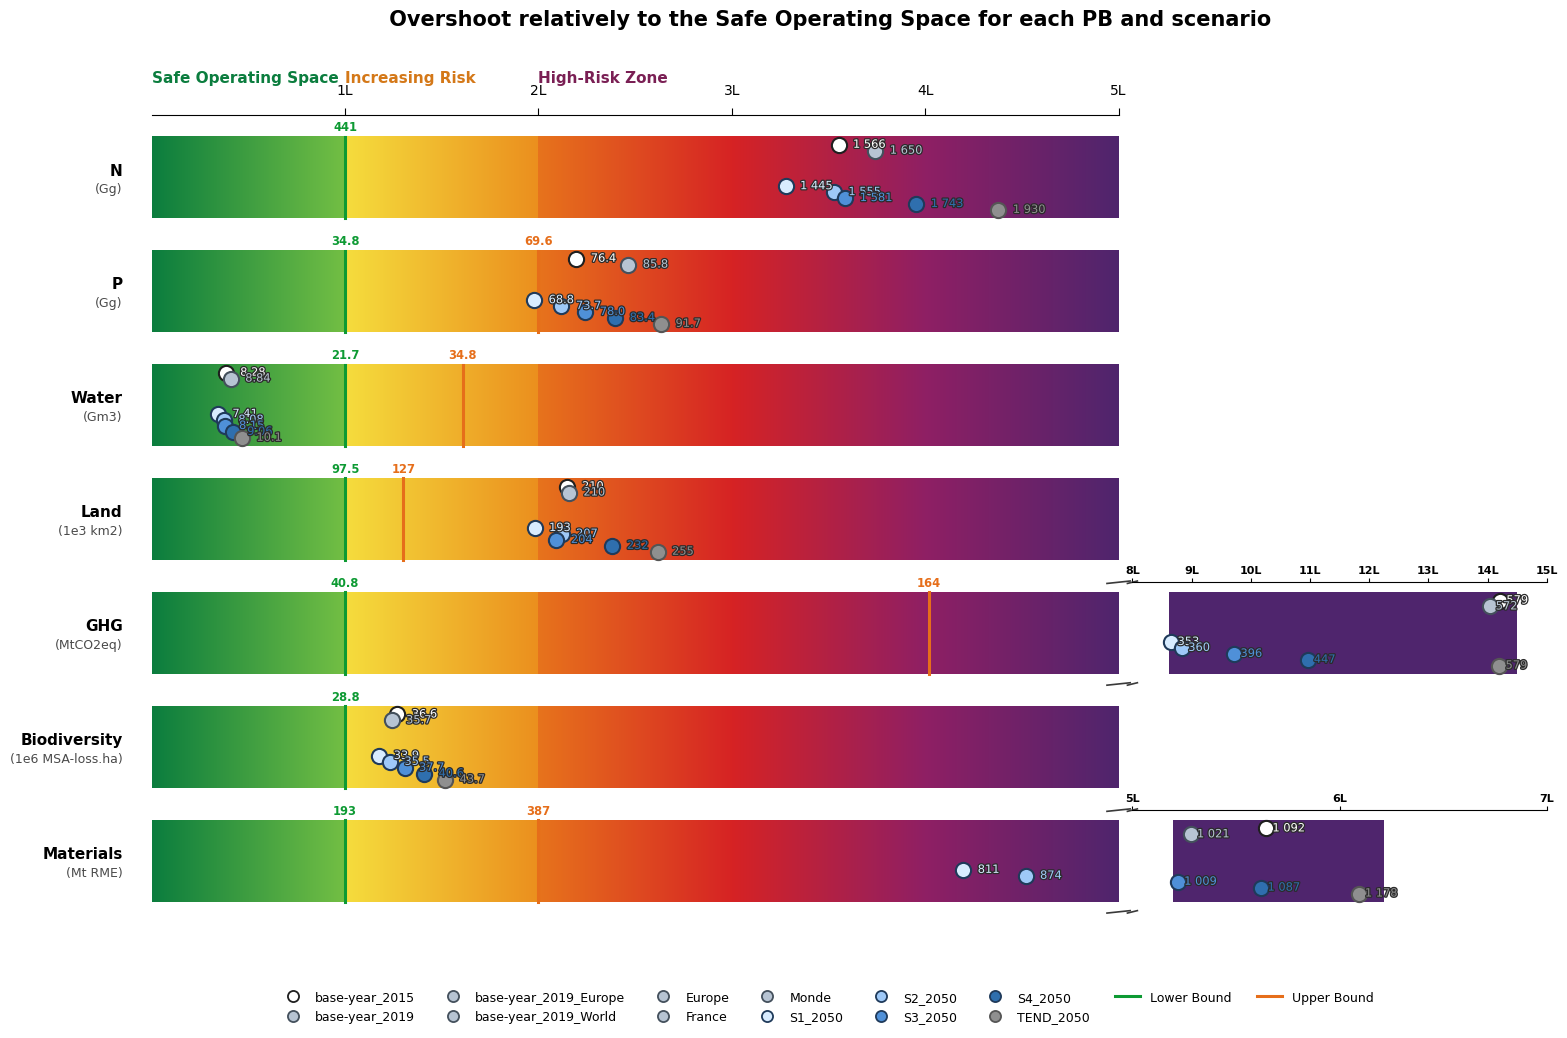

In [9]:
# ============================================================================
# 7. VISUALISATION "OVERSHOOT / SAFE OPERATING SPACE" (TOUS SCENARIOS)
# ============================================================================

import re
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

SAFE_LIMIT_REL = 1.0
RISK_TRANSITION_REL = 2.0


def _fmt_abs(value):
    """Formate une valeur absolue pour annotation."""
    if value is None or not np.isfinite(value):
        return "NA"
    if abs(value) >= 1000:
        return f"{value:,.0f}".replace(",", " ")
    if abs(value) >= 100:
        return f"{value:.0f}"
    if abs(value) >= 10:
        return f"{value:.1f}"
    return f"{value:.2f}"


def _total_footprint(lp_payload):
    """Empreinte totale (domestique + importee) pour un sous-processus."""
    return float(lp_payload["domestique"].sum() + lp_payload["importé"].sum())


def _get_lp_unit(seuils_df, subprocess_name):
    """Recupere l'unite d'affichage pour un LP."""
    for unit_row in ["Unité affichage"]:
        try:
            if unit_row in seuils_df.index and subprocess_name in seuils_df.columns:
                val = seuils_df.loc[unit_row, subprocess_name]
                if val is not None and str(val).lower() != "nan":
                    return str(val)
        except (KeyError, TypeError):
            pass
    return ""


def _scenario_style_map(scenario_names):
    """
    Associe chaque dossier de scenario a une couleur:
    - base-year_2015: blanc
    - tendanciel: gris
    - S1..S4: degrade de bleus
    """
    styles = {}

    blue_scale = {
        "s1": "#d8ecff",
        "s2": "#9ec9f8",
        "s3": "#4f90d8",
        "s4": "#2f6fae"
    }

    for raw_name in scenario_names:
        name_low = raw_name.lower()

        if "base-year_2015" in name_low:
            styles[raw_name] = {"face": "white", "edge": "#1f1f1f"}
            continue

        if "tend" in name_low:
            styles[raw_name] = {"face": "#8f8f8f", "edge": "#555555"}
            continue

        matched = False
        for s_key, blue_color in blue_scale.items():
            if re.search(rf"(^|[^a-z0-9]){s_key}([^a-z0-9]|$)", name_low):
                styles[raw_name] = {"face": blue_color, "edge": "#1f3a5a"}
                matched = True
                break

        if not matched:
            styles[raw_name] = {"face": "#b7c4d3", "edge": "#44505c"}

    return styles


def _draw_gradient_segment(ax, x0, x1, colors, y0=0.10, y1=0.90):
    """Dessine un segment horizontal avec gradient continu."""
    if x1 <= x0:
        return
    grad = np.linspace(0, 1, 512).reshape(1, -1)
    cmap = LinearSegmentedColormap.from_list("lp_grad", colors)
    ax.imshow(
        grad,
        extent=[x0, x1, y0, y1],
        aspect="auto",
        cmap=cmap,
        interpolation="bicubic",
        zorder=0
    )


def _draw_lp_background(ax, x_min, x_max):
    """Fond identique pour toutes les LP avec transition jaune/orange -> orange/rouge a 2L."""
    _draw_gradient_segment(ax, max(x_min, 0), min(x_max, SAFE_LIMIT_REL), ["#0b7d3e", "#73bf44"])
    _draw_gradient_segment(ax, max(x_min, SAFE_LIMIT_REL), min(x_max, RISK_TRANSITION_REL), ["#f5dd3d", "#eb8f1e"])
    _draw_gradient_segment(ax, max(x_min, RISK_TRANSITION_REL), x_max, ["#e7731c", "#d62324", "#8f1f64", "#4f256d"])


def _draw_above_5_uniform(ax, x_min, x_max):
    """Au-dela de 5L, couleur uniforme egale a la couleur atteinte a 5L."""
    if x_max <= x_min:
        return
    ax.axvspan(x_min, x_max, ymin=0.10, ymax=0.90, facecolor="#4f256d", edgecolor="none", zorder=0)


def _set_break_axis_ticks(ax_ext, overflow_points):
    """Affiche des graduations lisibles sur le segment de droite apres le saut."""
    x_min, x_max = ax_ext.get_xlim()
    int_min = int(np.floor(x_min))
    int_max = int(np.ceil(x_max))

    if int_max < int_min:
        int_min, int_max = int_max, int_min

    ticks = list(range(int_min, int_max + 1))

    # Si la plage est large, on reduit la densite des ticks en gardant des entiers
    if len(ticks) > 8:
        step = max(1, int(np.ceil((int_max - int_min) / 7)))
        ticks = list(range(int_min, int_max + 1, step))
        if ticks[-1] != int_max:
            ticks.append(int_max)

    labels = [f"{t}L" for t in ticks]

    ax_ext.set_xticks(ticks)
    ax_ext.set_xticklabels(labels, fontsize=8, fontweight="bold")


def create_overshoot_safe_space_figure(all_scenarios_data, seuils_df, scenario_names, x_main_max=5.0):
    """
    Cree une figure multi-LP de type Overshoot / Safe Operating Space.

    Axe X: relatif a la limite basse (LB = 1L).
    - Limite haute: UB/LB
    - Empreinte scenario: Empreinte/LB
    """
    if not all_scenarios_data:
        raise ValueError("all_scenarios_data est vide")

    first_scenario_data = all_scenarios_data[REFERENCE_SCENARIO_IDX]
    subprocesses = list(first_scenario_data.keys())
    n_lp = len(subprocesses)

    scenario_style = _scenario_style_map(scenario_names)

    # Un niveau vertical par scenario pour eviter toute superposition
    if len(scenario_names) == 1:
        y_levels = np.array([0.5])
    else:
        y_levels = np.linspace(0.82, 0.18, len(scenario_names))
    scenario_to_y = {name: y for name, y in zip(scenario_names, y_levels)}

    fig = plt.figure(figsize=(18, max(8, 1.2 * n_lp + 1.8)))
    gs = fig.add_gridspec(
        n_lp,
        2,
        width_ratios=[7.0, 3.0],
        hspace=0.12,
        wspace=0.02
    )

    top_main_ax = None

    for row_idx, subprocess_name in enumerate(subprocesses):
        ax = fig.add_subplot(gs[row_idx, 0])
        ax_ext = fig.add_subplot(gs[row_idx, 1], sharey=ax)
        ax.set_zorder(3)
        ax_ext.set_zorder(2)
        ax_ext.patch.set_alpha(0.0)

        if row_idx == 0:
            top_main_ax = ax

        lb_val = None
        ub_val = None
        unit_text = _get_lp_unit(seuils_df, subprocess_name)

        try:
            if THRESHOLD_PARAM_LB in seuils_df.index and subprocess_name in seuils_df.columns:
                value = seuils_df.loc[THRESHOLD_PARAM_LB, subprocess_name]
                if pd.notna(value) and value > 0:
                    lb_val = float(value)
        except (KeyError, TypeError, ValueError):
            lb_val = None

        try:
            if THRESHOLD_PARAM_UB in seuils_df.index and subprocess_name in seuils_df.columns:
                value = seuils_df.loc[THRESHOLD_PARAM_UB, subprocess_name]
                if pd.notna(value) and value > 0:
                    ub_val = float(value)
        except (KeyError, TypeError, ValueError):
            ub_val = None

        if lb_val is None or lb_val <= 0:
            ax.text(
                0.5,
                0.5,
                f"{subprocess_name}: limite basse manquante",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=10,
                color="#7a7a7a"
            )
            ax.set_xlim(0, x_main_max)
            ax.set_ylim(0, 1)
            ax.set_yticks([])
            ax_ext.set_visible(False)
            continue

        ub_rel = (ub_val / lb_val) if (ub_val is not None and ub_val > 0) else None

        points = []
        for scenario_idx, scenario_data in enumerate(all_scenarios_data):
            if subprocess_name not in scenario_data:
                continue

            total_abs = _total_footprint(scenario_data[subprocess_name])
            rel_x = total_abs / lb_val

            if np.isfinite(rel_x):
                scenario_name = scenario_names[scenario_idx]
                y_pos = scenario_to_y[scenario_name]
                points.append((scenario_idx, scenario_name, total_abs, rel_x, y_pos))

        overflow = [p for p in points if p[3] > x_main_max]
        use_break = len(overflow) > 0

        ax.set_xlim(0, x_main_max)
        ax.set_ylim(0, 1)
        _draw_lp_background(ax, 0, x_main_max)

        if use_break:
            overflow_x = [p[3] for p in overflow]
            x2_min = min(overflow_x) * 0.995
            x2_max = max(overflow_x) * 1.02

            if (x2_max - x2_min) < 0.5:
                mid = 0.5 * (x2_min + x2_max)
                x2_min = mid - 0.25
                x2_max = mid + 0.25

            ax_ext.set_xlim(x2_min, x2_max)
            ax_ext.set_ylim(0, 1)
            _draw_above_5_uniform(ax_ext, x2_min, x2_max)
            _set_break_axis_ticks(ax_ext, overflow)

            # Marque visuelle du saut
            d = 0.012
            kwargs_main = dict(transform=ax.transAxes, color="#3a3a3a", clip_on=False, linewidth=1.2)
            ax.plot((1 - d, 1 + d), (-d, +d), **kwargs_main)
            ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs_main)

            kwargs_ext = dict(transform=ax_ext.transAxes, color="#3a3a3a", clip_on=False, linewidth=1.2)
            ax_ext.plot((-d, +d), (-d, +d), **kwargs_ext)
            ax_ext.plot((-d, +d), (1 - d, 1 + d), **kwargs_ext)
        else:
            ax_ext.set_visible(False)

        # Traits vert/orange (independants du gradient)
        ax.axvline(1, ymin=0.10, ymax=0.90, color="#0d9a33", linewidth=2.2, zorder=3)
        if ub_rel is not None and ub_rel <= x_main_max:
            ax.axvline(ub_rel, ymin=0.10, ymax=0.90, color="#e66e1a", linewidth=2.2, zorder=3)

        # Valeurs absolues des limites
        ax.text(
            1,
            0.93,
            _fmt_abs(lb_val),
            color="#0d9a33",
            fontsize=8.3,
            fontweight="bold",
            ha="center",
            va="bottom",
            zorder=5
        )

        if ub_rel is not None and ub_rel <= x_main_max:
            ax.text(
                ub_rel,
                0.93,
                _fmt_abs(ub_val),
                color="#e66e1a",
                fontsize=8.3,
                fontweight="bold",
                ha="center",
                va="bottom",
                zorder=5
            )

        # Bulles + valeur absolue a droite
        for _, scenario_name, total_abs, rel_x, y_pos in points:
            style = scenario_style.get(scenario_name, {"face": "#b7c4d3", "edge": "#44505c"})

            target_ax = ax_ext if (use_break and rel_x > x_main_max and ax_ext.get_visible()) else ax
            x_span = target_ax.get_xlim()[1] - target_ax.get_xlim()[0]
            x_text = rel_x + x_span * 0.015

            target_ax.scatter(
                rel_x,
                y_pos,
                s=120,
                marker="o",
                facecolor=style["face"],
                edgecolor=style["edge"],
                linewidth=1.5,
                zorder=10
            )

            txt = target_ax.text(
                x_text,
                y_pos,
                _fmt_abs(total_abs),
                color=style["face"],
                fontsize=8.2,
                ha="left",
                va="center",
                zorder=11,
                clip_on=False
            )
            txt.set_path_effects([pe.withStroke(linewidth=1.8, foreground="#2b2b2b")])

        # Nom LP + unite sous le nom
        ax.text(
            -0.03,
            0.57,
            subprocess_name,
            transform=ax.transAxes,
            ha="right",
            va="center",
            fontsize=11,
            fontweight="bold"
        )
        if unit_text:
            ax.text(
                -0.03,
                0.39,
                f"({unit_text})",
                transform=ax.transAxes,
                ha="right",
                va="center",
                fontsize=9,
                fontweight="normal",
                color="#4a4a4a"
            )

        # Habillage epure
        for axis in (ax, ax_ext):
            if not axis.get_visible():
                continue
            axis.set_yticks([])
            axis.grid(False)
            axis.spines["left"].set_visible(False)
            axis.spines["right"].set_visible(False)
            axis.spines["bottom"].set_visible(False)
            if axis is ax:
                axis.spines["top"].set_visible(row_idx == 0)
            else:
                axis.spines["top"].set_visible(use_break and axis.get_visible())
            axis.xaxis.tick_top()
            axis.tick_params(axis="x", length=4, pad=4)

        # Axe principal: graduations seulement sur la 1ere ligne
        if row_idx != 0:
            ax.tick_params(axis="x", labeltop=False, top=False)

        # Segment de droite: garder les graduations visibles pour lire l'overshoot
        if use_break and ax_ext.get_visible():
            ax_ext.tick_params(axis="x", labeltop=True, top=True, labelsize=8, length=3, pad=2)

    # Axe X principal commun en haut (1L, 2L, 3L...)
    if top_main_ax is not None:
        top_main_ax.set_xticks(np.arange(1, int(x_main_max) + 1, 1))
        top_main_ax.set_xticklabels([f"{i}L" for i in range(1, int(x_main_max) + 1)], fontsize=10, fontweight="bold")
        top_main_ax.spines["top"].set_position(("outward", 8))
        top_main_ax.tick_params(axis="x", pad=8, length=5)

        top_main_ax.text(
            0.00,
            1.44,
            "Safe Operating Space",
            transform=top_main_ax.transAxes,
            color="#0b7d3e",
            fontsize=11,
            fontweight="bold",
            ha="left"
        )
        top_main_ax.text(
            0.20,
            1.44,
            "Increasing Risk",
            transform=top_main_ax.transAxes,
            color="#d47818",
            fontsize=11,
            fontweight="bold",
            ha="left"
        )
        top_main_ax.text(
            0.40,
            1.44,
            "High-Risk Zone",
            transform=top_main_ax.transAxes,
            color="#7a1f54",
            fontsize=11,
            fontweight="bold",
            ha="left"
        )

    # Legende des scenarios
    legend_handles = []
    for scenario_name in scenario_names:
        style = scenario_style.get(scenario_name, {"face": "#b7c4d3", "edge": "#44505c"})
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=style["face"],
                markeredgecolor=style["edge"],
                markeredgewidth=1.3,
                markersize=8,
                label=scenario_name
            )
        )

    limit_handles = [
        Line2D([0], [0], color="#0d9a33", linewidth=2.2, label="Lower Bound"),
        Line2D([0], [0], color="#e66e1a", linewidth=2.2, label="Upper Bound")
    ]

    fig.legend(
        handles=legend_handles + limit_handles,
        loc="lower center",
        ncol=min(8, len(legend_handles) + len(limit_handles)),
        bbox_to_anchor=(0.5, -0.01),
        frameon=False,
        fontsize=9
    )

    fig.suptitle(
        " Overshoot relatively to the Safe Operating Space for each PB and scenario",
        fontsize=15,
        fontweight="bold",
        y=0.995
    )

    plt.tight_layout(rect=[0.10, 0.06, 0.98, 0.93])
    return fig


def build_and_plot_overshoot_figure():
    """Pipeline de calcul + visualisation pour tous les scenarios."""
    facteurs_carac_df = load_facteurs_carac()
    bridge_matrices_df = load_bridge_matrices()
    seuils_df = load_seuils()

    all_scenarios_data = []

    for scenario_folder in SCENARIO_FOLDERS:
        data_by_subprocess, _ = process_scenario(
            scenario_folder,
            facteurs_carac_df,
            bridge_matrices_df,
            seuils_df
        )
        all_scenarios_data.append(data_by_subprocess)

    fig = create_overshoot_safe_space_figure(
        all_scenarios_data=all_scenarios_data,
        seuils_df=seuils_df,
        scenario_names=SCENARIO_NAMES,
        x_main_max=5.0
    )

    output_path = Path(FIGURES_DIR) / "overshoot_safe_operating_space_all_scenarios.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Figure sauvegardee: {output_path}")

    return fig


fig_overshoot = build_and_plot_overshoot_figure()
plt.show()

Chargement des facteurs de caractérisation...
  ✓ 170 lignes chargées
Sous-processus traces: 7
Categories: ['Riz', 'Autres', 'Bœuf', 'Porc', 'Poulet', 'Autres viandes', 'Produits laitiers', 'Poisson']
Figure sauvegardee: C:\Users\Arnaud\Documents\PlaneFR\figures\bubble_chart_reference_scenario_weighted.png


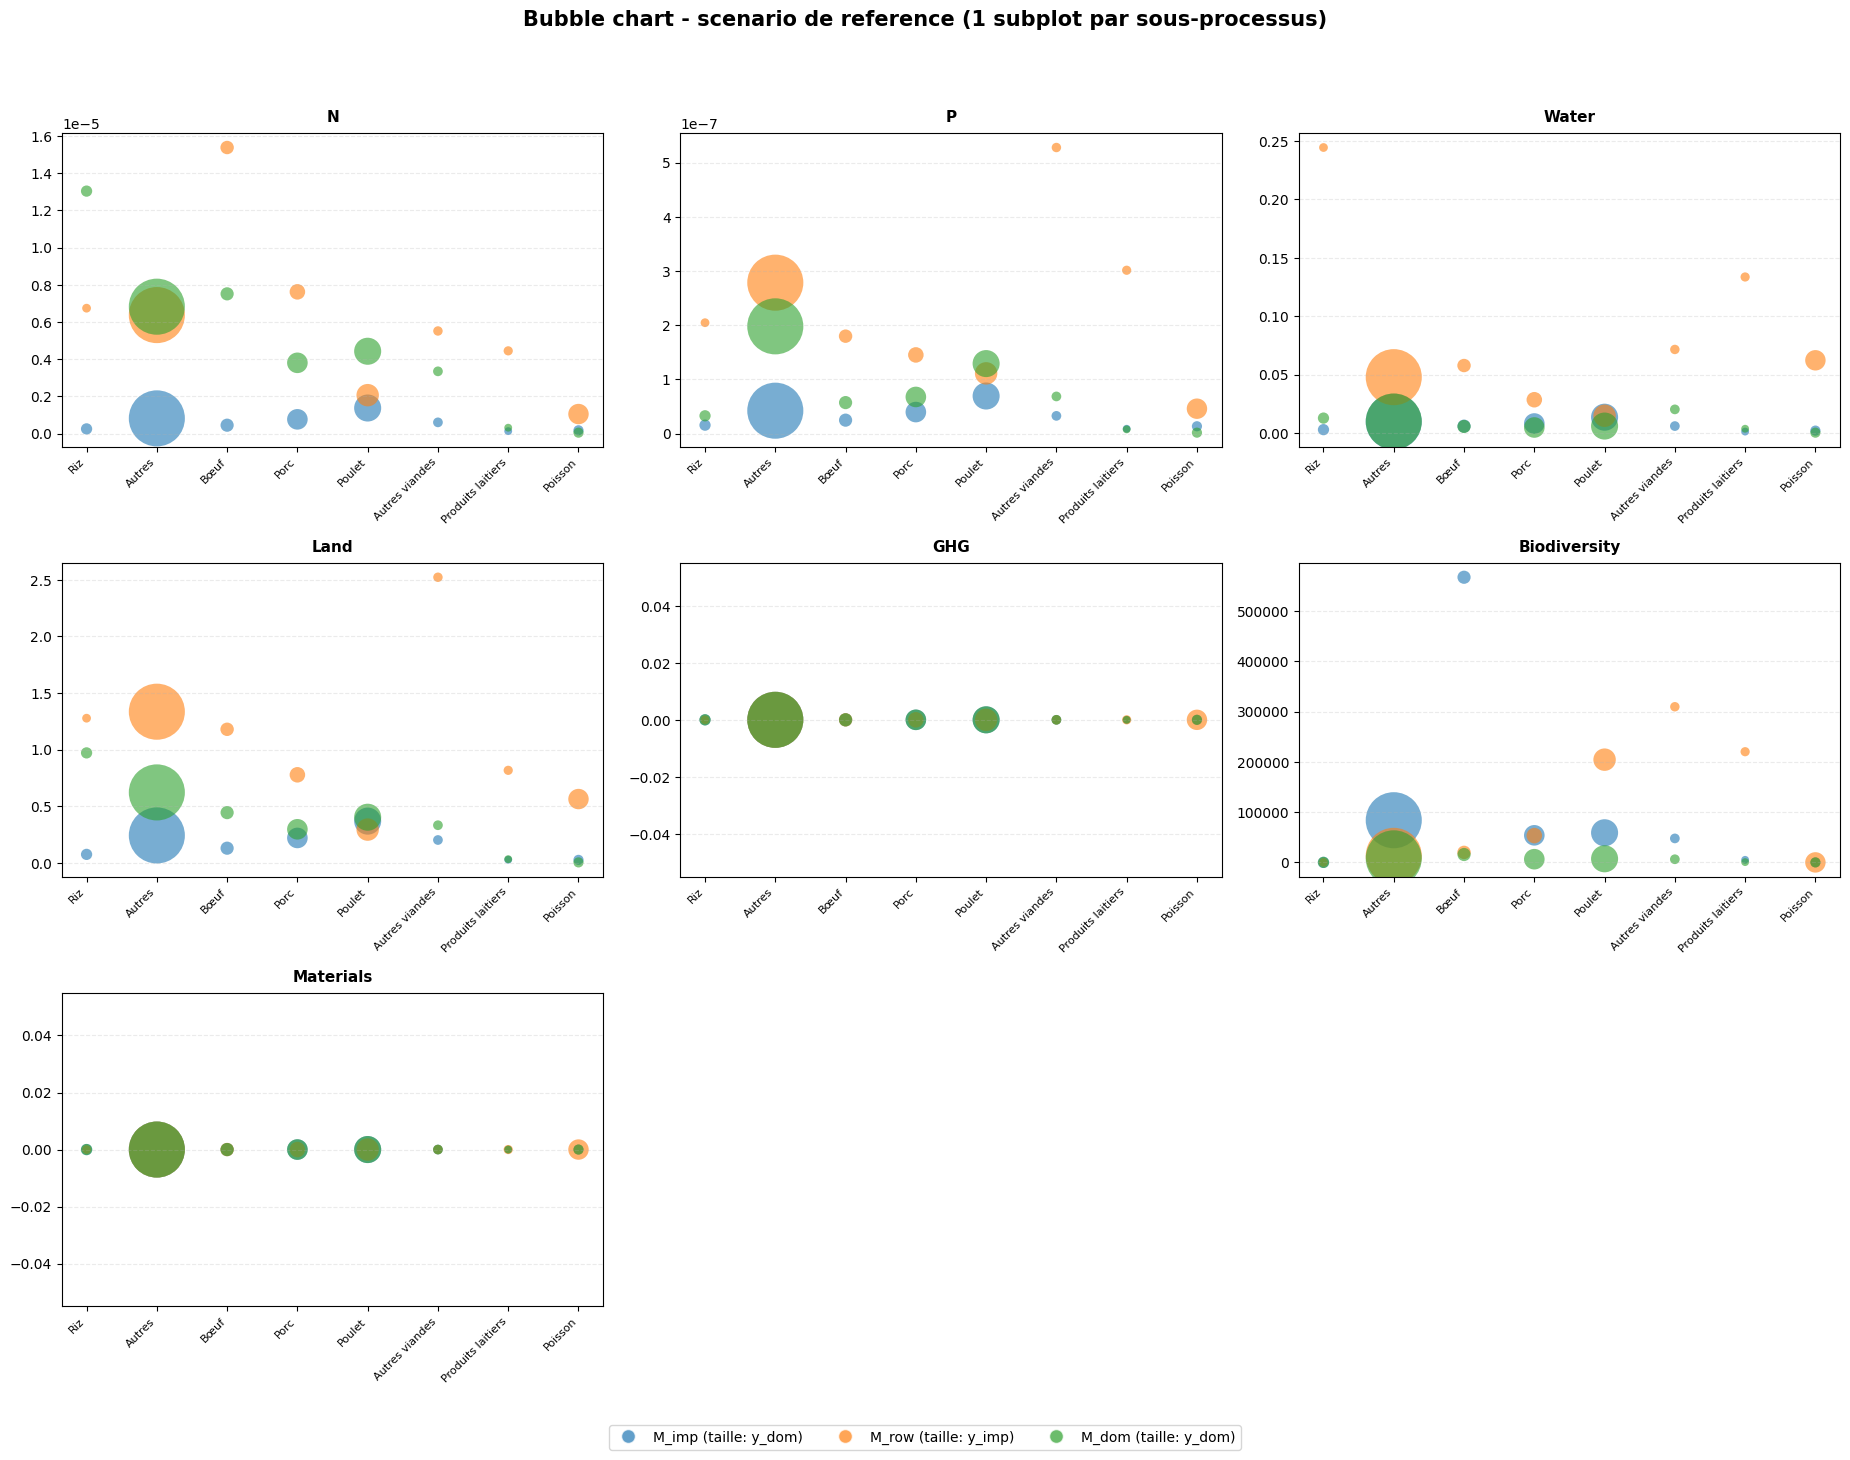

In [10]:
# ============================================================================
# 7. BUBBLE CHART - INTENSITES PAR SOUS-PROCESSUS (Scenario de reference)
# ============================================================================
"""
Objectif:
- 1 subplot par sous-processus (comme les figures precedentes)
- Pour chaque categorie (abscisse): 3 bulles superposees verticalement
  1) y = M_imp ; taille ~ y_dom
  2) y = M_row ; taille ~ y_imp
  3) y = M_dom ; taille ~ y_dom

Aggregation demandee:
- Bridge de la feuille 'M' (colonnes 4 a 8, 200 lignes x 5 colonnes)
- Pour M: moyenne ponderee par Y, avec poids categorie-specifiques
  (ex: Housing -> colonne Y Residential, Mobility -> colonne Y Transport)
"""

import math

# Facteur visuel de taille des bulles (proportionnel apres normalisation)
BUBBLE_SCALE = 1600.0
BUBBLE_MIN_SIZE = 30.0


def load_bridge_m_matrix():
    """Charge le bridge 'M' (200 x 5) depuis bridge_matrices.xlsx."""
    m_raw = pd.read_excel(BRIDGE_MATRICES_FILE, sheet_name="Alimentation")

    # Colonnes incluses
    bridge_m = m_raw.iloc[:200, 3:].copy()

    # Index produit (3e colonne dans le fichier -> indice 2)
    bridge_m.index = m_raw.iloc[:200, 2].values

    # Conversion robuste en numerique (0/1)
    bridge_m = bridge_m.apply(pd.to_numeric, errors="coerce").fillna(0)
    bridge_m = (bridge_m > 0).astype(int)
    return bridge_m


def filter_and_weight_matrix(matrix_df, extension_factor_map):
    """Reprend strictement le filtrage + ponderation deja utilises pour d_cba."""
    weighted_rows = []
    for idx, row in matrix_df.iterrows():
        idx_value = idx[0] if isinstance(idx, tuple) else idx
        if idx_value in extension_factor_map:
            weighted_rows.append(row * extension_factor_map[idx_value])

    if not weighted_rows:
        return pd.Series(dtype=float)

    summed = pd.DataFrame(weighted_rows).sum(axis=0)
    if isinstance(summed.index, pd.MultiIndex):
        summed.index = summed.index.get_level_values(-1)
    return summed


def load_m_matrix(scenario_folder_path, lp_name, kind):
    """Charge M_k/M_RoW pour un LP et un type (dom/imp/row)."""
    if kind == "dom":
        folder = f"dom_{lp_name}"
        filename = "M_k.pkl"
    elif kind == "imp":
        folder = f"imp_{lp_name}"
        filename = "M_k.pkl"
    elif kind == "row":
        folder = f"imp_{lp_name}"
        filename = "M_RoW.pkl"
    else:
        raise ValueError("kind must be 'dom', 'imp', or 'row'")

    file_path = Path(scenario_folder_path) / "extensions" / folder / filename
    if not file_path.exists():
        return None
    return pd.read_pickle(file_path)


def get_y_blocks(reference_folder):
    """
    Charge Y.pkl et retourne les blocs 200x5 pour dom et imp.
    - Somme colonne 6..10 pour compatibilite avec l'ancien flux
    - Conserve aussi les 5 colonnes detaillees pour la ponderation
    """
    y_path = Path(reference_folder) / "system" / "Y.pkl"
    if not y_path.exists():
        raise FileNotFoundError(f"Y.pkl not found: {y_path}")

    y_df = pd.read_pickle(y_path)

    # Somme des colonnes 0..5 (slice 0:6)
    y_sum_0_6 = y_df.iloc[:, 0:6].sum(axis=1)

    # Conserver un format DataFrame a 5 colonnes (compatible pipeline)
    y_5cols = pd.concat([y_sum_0_6] * 5, axis=1)
    y_5cols.columns = [f"Y_sum_0_6_{i+1}" for i in range(5)]

    # Decoupage demande par specification initiale
    y_dom_5 = y_5cols.iloc[0:200].copy()   # 200 lignes
    y_imp_5 = y_5cols.iloc[200:400].copy() # 200 lignes

    return y_dom_5, y_imp_5


def build_bridge_to_y_mapping(bridge_cols, y_cols):
    """
    Associe chaque colonne du bridge M a une colonne de Y pour les poids.
    Regles speciales:
    - Housing -> Residential
    - Mobility -> Transport
    Fallback: correspondance positionnelle.
    """
    mapping = {}
    y_cols_l = [str(c).lower() for c in y_cols]

    def find_y_col(preferred_tokens, fallback_idx):
        for tok in preferred_tokens:
            for i, yc in enumerate(y_cols_l):
                if tok in yc:
                    return y_cols[i]
        return y_cols[min(fallback_idx, len(y_cols) - 1)]

    for i, bcol in enumerate(bridge_cols):
        b = str(bcol).lower()

        if "housing" in b:
            mapping[bcol] = find_y_col(["residential", "housing"], i)
        elif "mobility" in b or "transport" in b:
            mapping[bcol] = find_y_col(["transport", "mobility"], i)
        elif "food" in b:
            mapping[bcol] = find_y_col(["food", "nour"], i)
        else:
            mapping[bcol] = y_cols[min(i, len(y_cols) - 1)]

    return mapping


def align_series_to_bridge(vector, bridge_m):
    """Aligne un vecteur 200 sur l'index bridge_m de maniere robuste."""
    vec = vector.copy()
    if len(vec) == len(bridge_m):
        vec.index = bridge_m.index
    else:
        vec = vec.reindex(bridge_m.index)
    return vec.fillna(0.0)


def weighted_mean_by_category(m_vector, y_5cols, bridge_m, bridge_to_y_col):
    """
    Calcule M agrege par categorie via moyenne ponderee par Y colonne-specifique.
    Pour chaque categorie c:
      M_c = sum_i( M_i * Y_i,col(c) * I(i in c) ) / sum_i( Y_i,col(c) * I(i in c) )
    """
    m_vec = align_series_to_bridge(m_vector, bridge_m)
    y_aligned = y_5cols.copy()
    if len(y_aligned) == len(bridge_m):
        y_aligned.index = bridge_m.index
    else:
        y_aligned = y_aligned.reindex(bridge_m.index)
    y_aligned = y_aligned.fillna(0.0)

    out = {}
    for cat in bridge_m.columns:
        mask = bridge_m[cat] == 1
        y_col = bridge_to_y_col[cat]

        weights = y_aligned.loc[mask, y_col].astype(float)
        values = m_vec.loc[mask].astype(float)

        denom = float(weights.sum())
        if denom > 0:
            out[cat] = float((values * weights).sum() / denom)
        else:
            out[cat] = 0.0

    return pd.Series(out)


def aggregate_y_for_sizes(y_5cols, bridge_m, bridge_to_y_col):
    """Construit y_dom/y_imp par categorie pour la taille des bulles."""
    y_aligned = y_5cols.copy()
    if len(y_aligned) == len(bridge_m):
        y_aligned.index = bridge_m.index
    else:
        y_aligned = y_aligned.reindex(bridge_m.index)
    y_aligned = y_aligned.fillna(0.0)

    out = {}
    for cat in bridge_m.columns:
        mask = bridge_m[cat] == 1
        y_col = bridge_to_y_col[cat]
        out[cat] = float(y_aligned.loc[mask, y_col].sum())
    return pd.Series(out)


def compute_subprocess_m_vectors(reference_folder, facteurs_carac_df, bridge_m, y_dom_5, y_imp_5):
    """
    Calcule M_dom/M_imp/M_row agreges pour chaque sous-processus.
    Reprend la logique precedemment utilisee:
    - Sous-processus -> liste des LP associes
    - Chargement M par LP puis somme entre LP pour le sous-processus
    - Aggregation finale par moyenne ponderee sur 5 categories
    """
    subprocess_to_lp = get_unique_subprocesses(facteurs_carac_df)
    bridge_to_y_col = build_bridge_to_y_mapping(list(bridge_m.columns), list(y_dom_5.columns))

    data_by_subprocess = {}

    for subprocess_name, lp_list in subprocess_to_lp.items():
        agg_dom = None
        agg_imp = None
        agg_row = None

        # Filtre facteurs du sous-processus
        sub_mask = facteurs_carac_df["Sous-processus"] == subprocess_name
        sub_data = facteurs_carac_df[sub_mask]
        extension_factor_map = dict(
            zip(sub_data["Extensions exiobase"].values, sub_data["Facteurs de caractérisation"].values)
        )

        for lp_name in lp_list:
            m_dom_df = load_m_matrix(reference_folder, lp_name, "dom")
            m_imp_df = load_m_matrix(reference_folder, lp_name, "imp")
            m_row_df = load_m_matrix(reference_folder, lp_name, "row")

            if m_dom_df is None and m_imp_df is None and m_row_df is None:
                continue

            v_dom = filter_and_weight_matrix(m_dom_df, extension_factor_map) if m_dom_df is not None else pd.Series(dtype=float)
            v_imp = filter_and_weight_matrix(m_imp_df, extension_factor_map) if m_imp_df is not None else pd.Series(dtype=float)
            v_row = filter_and_weight_matrix(m_row_df, extension_factor_map) if m_row_df is not None else pd.Series(dtype=float)

            if agg_dom is None:
                agg_dom = v_dom.copy()
                agg_imp = v_imp.copy()
                agg_row = v_row.copy()
            else:
                agg_dom = agg_dom.add(v_dom, fill_value=0)
                agg_imp = agg_imp.add(v_imp, fill_value=0)
                agg_row = agg_row.add(v_row, fill_value=0)

        if agg_dom is None:
            continue

        m_dom_cat = weighted_mean_by_category(agg_dom, y_dom_5, bridge_m, bridge_to_y_col)
        m_imp_cat = weighted_mean_by_category(agg_imp, y_dom_5, bridge_m, bridge_to_y_col)
        m_row_cat = weighted_mean_by_category(agg_row, y_imp_5, bridge_m, bridge_to_y_col)

        data_by_subprocess[subprocess_name] = {
            "M_dom": m_dom_cat,
            "M_imp": m_imp_cat,
            "M_row": m_row_cat,
        }

    y_dom_cat = aggregate_y_for_sizes(y_dom_5, bridge_m, bridge_to_y_col)
    y_imp_cat = aggregate_y_for_sizes(y_imp_5, bridge_m, bridge_to_y_col)

    return data_by_subprocess, y_dom_cat, y_imp_cat


def scale_bubble_sizes(values, scale=BUBBLE_SCALE, min_size=BUBBLE_MIN_SIZE):
    """Normalise les tailles pour eviter les bulles geantes tout en gardant la proportion."""
    arr = np.asarray(values, dtype=float)
    arr = np.where(np.isfinite(arr) & (arr > 0), arr, 0.0)

    if arr.max() <= 0:
        return np.full_like(arr, min_size, dtype=float)

    rel = arr / arr.max()
    return min_size + rel * scale


def plot_bubble_chart(data_by_subprocess, y_dom_cat, y_imp_cat):
    """Trace 1 subplot par sous-processus avec 3 bulles par categorie."""
    subprocesses = list(data_by_subprocess.keys())
    n_sp = len(subprocesses)
    if n_sp == 0:
        print("Aucune donnee a tracer.")
        return None, None

    categories = list(y_dom_cat.index)
    x_pos = np.arange(len(categories))

    n_cols = 3
    n_rows = int(math.ceil(n_sp / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.2 * n_cols, 4.8 * n_rows))
    axes = np.array(axes).reshape(-1)

    colors = {
        "M_imp": "#1f77b4",
        "M_row": "#ff7f0e",
        "M_dom": "#2ca02c",
    }

    size_dom = scale_bubble_sizes(y_dom_cat.reindex(categories).values)
    size_imp = scale_bubble_sizes(y_imp_cat.reindex(categories).values)

    for i, sp in enumerate(subprocesses):
        ax = axes[i]
        payload = data_by_subprocess[sp]

        m_imp_vals = payload["M_imp"].reindex(categories).fillna(0).values
        m_row_vals = payload["M_row"].reindex(categories).fillna(0).values
        m_dom_vals = payload["M_dom"].reindex(categories).fillna(0).values

        # 3 bulles superposees sur la meme abscisse
        ax.scatter(x_pos, m_imp_vals, s=size_dom, c=colors["M_imp"], alpha=0.6, label="M_imp (taille: y_dom)", edgecolors="none")
        ax.scatter(x_pos, m_row_vals, s=size_imp, c=colors["M_row"], alpha=0.6, label="M_row (taille: y_imp)", edgecolors="none")
        ax.scatter(x_pos, m_dom_vals, s=size_dom, c=colors["M_dom"], alpha=0.6, label="M_dom (taille: y_dom)", edgecolors="none")

        ax.set_title(sp, fontsize=11, fontweight="bold", pad=8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(categories, rotation=45, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.25, linestyle="--")

    for i in range(n_sp, len(axes)):
        axes[i].set_visible(False)

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["M_imp"], markersize=10, alpha=0.7, label="M_imp (taille: y_dom)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["M_row"], markersize=10, alpha=0.7, label="M_row (taille: y_imp)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["M_dom"], markersize=10, alpha=0.7, label="M_dom (taille: y_dom)"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.01))

    fig.suptitle("Bubble chart - scenario de reference (1 subplot par sous-processus)", fontsize=15, fontweight="bold", y=0.995)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    return fig, axes


# ============================================================================
# EXECUTION
# ============================================================================
reference_folder = SCENARIO_FOLDERS[REFERENCE_SCENARIO_IDX]

if "facteurs_carac_df" in globals():
    facteurs_carac_df = globals()["facteurs_carac_df"]
else:
    facteurs_carac_df = load_facteurs_carac()

# Bridge M + Y blocs detailes
bridge_m = load_bridge_m_matrix()
y_dom_5, y_imp_5 = get_y_blocks(reference_folder)

# Calcul M et Y agreges pour le bubble chart
data_by_subprocess_bubble, y_dom_cat, y_imp_cat = compute_subprocess_m_vectors(
    reference_folder=reference_folder,
    facteurs_carac_df=facteurs_carac_df,
    bridge_m=bridge_m,
    y_dom_5=y_dom_5,
    y_imp_5=y_imp_5,
)

print(f"Sous-processus traces: {len(data_by_subprocess_bubble)}")
print(f"Categories: {list(y_dom_cat.index)}")

fig_bubble, axes_bubble = plot_bubble_chart(data_by_subprocess_bubble, y_dom_cat, y_imp_cat)
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)
output_path_bubble = Path(FIGURES_DIR) / "bubble_chart_reference_scenario_weighted.png"
if fig_bubble is not None:
    fig_bubble.savefig(output_path_bubble, dpi=300, bbox_inches="tight")
    print(f"Figure sauvegardee: {output_path_bubble}")
